# Vanilla RL Experiment - Data Loading and Unification

This notebook loads training and test data from vanilla RL generalization matrix experiments, unifies data across tasks, and computes averages across multiple runs.

## Experiment Structure

**Selected Experiment:** `generalization_matrix_871188`
- **15 Tasks** = 3 Games × 5 Opponent Ranges
- **Games:** Prisoner's Dilemma (PD), Hawk-Dove (HD), Stag-Hunt (SH)
- **Opponent Ranges:** very_low, low, mid, high, very_high
- **Multiple Runs:** Some tasks have 1-5 repetitions

## Data Files Per Task
Each task directory contains:
- **Training data:** `checkpoints/detailed_training_logs/detailed_training_log.csv` (~88K rows, 34 columns)
- **Test data:** `results/task_X_results.pkl` (9 test conditions per task)
- **Model checkpoints:** `checkpoints/*.pt` (every 100 epochs + final)

---
## 1. Imports and Setup

In [32]:
import numpy as np
import pandas as pd
import pickle
import json
from pathlib import Path
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

print("✓ Imports loaded")

✓ Imports loaded


## 2. Configuration and Constants

In [33]:
# Base directories
BASE_DIR = Path.cwd().parent.parent
EXPERIMENTS_DIR = BASE_DIR / "experiments"
OUTPUT_DIR = Path.cwd() / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

# Select experiment
EXPERIMENT_DIR = "generalization_matrix_871188"

# Game definitions
GAMES = ['prisoners-dilemma', 'hawk-dove', 'stag-hunt']
GAME_LABELS = ['PD', 'HD', 'SH']
GAME_FULL_NAMES = ['Prisoner\'s Dilemma', 'Hawk-Dove', 'Stag-Hunt']

# Opponent ranges (matching generalization_matrix_config.json)
OPPONENT_RANGES = ['very_low', 'low', 'mid', 'high', 'very_high']
OPP_LABELS = ['0.0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0']

# Opponent range boundaries (defection probabilities)
OPP_RANGE_BOUNDS = {
    'very_low': (0.0, 0.2),
    'low': (0.2, 0.4),
    'mid': (0.4, 0.6),
    'high': (0.6, 0.8),
    'very_high': (0.8, 1.0)
}

# Payoff ranges for normalization
GAME_PAYOFF_RANGES = {
    'prisoners-dilemma': (-3, 0),  # (P=lowest, T=best for defector)
    'hawk-dove': (-10, 10),         # (escalation cost, uncontested resource)
    'stag-hunt': (0, 5)             # (hare alone, stag together)
}

# Training conditions (15 total)
TRAINING_CONDITIONS = {}
task_id = 0
for game in GAMES:
    for opp_range in OPPONENT_RANGES:
        low, high = OPP_RANGE_BOUNDS[opp_range]
        # 3 opponent samples per range
        opp_probs = [low, (low + high) / 2, high]
        TRAINING_CONDITIONS[task_id] = (game, opp_range, opp_probs)
        task_id += 1

num_tasks = len(TRAINING_CONDITIONS)

print(f"✓ Configuration loaded")
print(f"   Experiment: {EXPERIMENT_DIR}")
print(f"   Tasks: {num_tasks} ({len(GAMES)} games × {len(OPPONENT_RANGES)} opponent ranges)")
print(f"   Base directory: {BASE_DIR}")

✓ Configuration loaded
   Experiment: generalization_matrix_871188
   Tasks: 15 (3 games × 5 opponent ranges)
   Base directory: c:\Users\User\OneDrive - huji.ac.il\מסמכים\Max_Planck\Cognitive-Therapy-fo-AI-


## 3. Helper Functions - Data Loading

In [34]:
def find_task_path(task_id):
    """
    Find the directory path for a specific task ID.
    If multiple runs exist, returns all matching directories.
    
    Args:
        task_id (int): Task ID from 0 to 14
        
    Returns:
        list: List of Path objects for all runs of this task
    """
    exp_dir = EXPERIMENTS_DIR / EXPERIMENT_DIR
    if not exp_dir.exists():
        return []
    
    # Look for all task directories matching pattern
    task_dirs = list(exp_dir.glob(f"generalization_matrix_task_{task_id}_*"))
    
    # Sort by timestamp (directory name) to get chronological order
    task_dirs.sort(key=lambda p: p.name)
    
    return task_dirs


def normalize_reward(reward, game_name):
    """
    Min-max normalize reward to [0, 1] based on game's payoff range.
    
    Args:
        reward (float): Raw reward value
        game_name (str): Name of the game
        
    Returns:
        float: Normalized reward in [0, 1]
    """
    min_r, max_r = GAME_PAYOFF_RANGES[game_name]
    if max_r == min_r:
        return 0.5
    return np.clip((reward - min_r) / (max_r - min_r), 0, 1)


def load_training_data(task_path):
    """
    Load training CSV log for a task and aggregate by epoch.
    
    Args:
        task_path (Path): Path to task directory
        
    Returns:
        pd.DataFrame or None: Epoch-aggregated training data if found, None otherwise
    """
    csv_path = task_path / "checkpoints" / "detailed_training_logs" / "detailed_training_log.csv"
    if not csv_path.exists():
        return None
    
    try:
        # Load detailed step-by-step data
        detailed_df = pd.read_csv(csv_path)
        
        # Aggregate by epoch to create episode-level statistics
        epoch_stats = detailed_df.groupby('epoch').agg({
            'agent_reward': ['mean', 'std', 'min', 'max', 'count'],
            'policy_prob_cooperate': 'mean',
            'total_loss': 'mean',
            'rl_loss': 'mean',
            'opponent_policy_loss': 'mean',
            'alpha': 'mean',
            'value_estimate': 'mean',
            'advantage': ['mean', 'std'],
            'gradient_norm': 'mean'
        }).reset_index()
        
        # Flatten multi-level columns
        epoch_stats.columns = ['_'.join(col).strip('_') if col[1] else col[0] 
                                for col in epoch_stats.columns]
        
        # Rename for clarity
        epoch_stats.rename(columns={
            'epoch': 'episode',
            'agent_reward_mean': 'avg_reward',
            'agent_reward_std': 'reward_std',
            'agent_reward_min': 'reward_min',
            'agent_reward_max': 'reward_max',
            'agent_reward_count': 'steps_per_epoch',
            'policy_prob_cooperate_mean': 'avg_cooperation',
            'total_loss_mean': 'avg_loss',
            'rl_loss_mean': 'avg_rl_loss',
            'opponent_policy_loss_mean': 'avg_opp_loss',
            'alpha_mean': 'avg_alpha',
            'value_estimate_mean': 'avg_value',
            'advantage_mean': 'avg_advantage',
            'advantage_std': 'advantage_std',
            'gradient_norm_mean': 'avg_gradient_norm'
        }, inplace=True)
        
        return epoch_stats
        
    except Exception as e:
        print(f"      Error loading training data: {e}")
        return None


def load_test_results(task_path):
    """
    Load test results pickle for a task.
    
    Args:
        task_path (Path): Path to task directory
        
    Returns:
        dict or None: Test results if found, None otherwise
    """
    results_dir = task_path / "results"
    if not results_dir.exists():
        return None
    
    pkl_files = list(results_dir.glob("*.pkl"))
    if not pkl_files:
        return None
    
    try:
        with open(pkl_files[0], 'rb') as f:
            return pickle.load(f)
    except Exception as e:
        print(f"      Error loading test results: {e}")
        return None


print("✓ Data loading helper functions defined")

✓ Data loading helper functions defined


## 4. Helper Functions - Data Unification and Averaging

In [35]:
def count_task_repetitions():
    """
    Count how many runs exist for each task.
    
    Returns:
        dict: {task_id: num_runs}
    """
    repetition_counts = {}
    for task_id in range(num_tasks):
        task_dirs = find_task_path(task_id)
        repetition_counts[task_id] = len(task_dirs)
    return repetition_counts


def aggregate_training_across_runs(task_id, run_data_list):
    """
    Aggregate training data across multiple runs of the same task.
    Computes mean, std, and 95% confidence intervals.
    
    Args:
        task_id (int): Task ID
        run_data_list (list): List of DataFrames, one per run
        
    Returns:
        pd.DataFrame: Aggregated statistics with columns:
            - episode, mean_reward, std_reward, ci_lower, ci_upper, 
            - mean_cooperation, std_cooperation, etc.
    """
    if not run_data_list:
        return None
    
    if len(run_data_list) == 1:
        # Only one run - no aggregation needed
        df = run_data_list[0].copy()
        df['n_runs'] = 1
        return df
    
    # Concatenate all runs
    for i, df in enumerate(run_data_list):
        df['run_id'] = i
    
    combined = pd.concat(run_data_list, ignore_index=True)
    
    # Aggregate by episode
    agg_funcs = {
        'avg_reward': ['mean', 'std', 'count'],
        'avg_cooperation': ['mean', 'std'],
        'avg_loss': ['mean', 'std'],
        'avg_rl_loss': ['mean', 'std'],
        'avg_opp_loss': ['mean', 'std'],
        'avg_alpha': ['mean', 'std'],
        'avg_value': ['mean', 'std'],
        'avg_advantage': ['mean', 'std'],
        'avg_gradient_norm': ['mean', 'std']
    }
    
    aggregated = combined.groupby('episode').agg(agg_funcs).reset_index()
    
    # Flatten columns
    aggregated.columns = ['_'.join(col).strip('_') if col[1] else col[0] 
                          for col in aggregated.columns]
    
    # Rename for clarity
    n_runs = aggregated['avg_reward_count'].iloc[0]
    aggregated['n_runs'] = n_runs
    
    # Compute 95% confidence intervals (± 1.96 * SEM)
    import scipy.stats as stats
    for metric in ['avg_reward', 'avg_cooperation', 'avg_loss']:
        mean_col = f'{metric}_mean'
        std_col = f'{metric}_std'
        if mean_col in aggregated.columns and std_col in aggregated.columns:
            sem = aggregated[std_col] / np.sqrt(n_runs)
            aggregated[f'{metric}_ci_lower'] = aggregated[mean_col] - 1.96 * sem
            aggregated[f'{metric}_ci_upper'] = aggregated[mean_col] + 1.96 * sem
    
    return aggregated


def aggregate_test_across_runs(task_id, test_results_list):
    """
    Aggregate test results across multiple runs of the same task.
    
    Args:
        task_id (int): Task ID
        test_results_list (list): List of test result dicts, one per run
        
    Returns:
        dict: Aggregated test statistics
    """
    if not test_results_list:
        return None
    
    if len(test_results_list) == 1:
        return test_results_list[0]
    
    # Extract evaluation_summaries from each run
    all_evals = []
    for run_results in test_results_list:
        if 'evaluation_summaries' in run_results:
            all_evals.append(run_results['evaluation_summaries'])
    
    if not all_evals:
        return None
    
    # For now, just take the first run's structure and add n_runs
    aggregated = {
        'evaluation_summaries': all_evals[0],
        'n_runs': len(all_evals),
        'all_runs': all_evals
    }
    
    return aggregated


print("✓ Data aggregation helper functions defined")

✓ Data aggregation helper functions defined


## 5. Load All Data

In [36]:
def load_all_task_data():
    """
    Load data from all tasks in the selected experiment.
    For tasks with multiple runs, aggregates across runs.
    
    Returns:
        dict: Dictionary containing:
            - 'raw_data': Per-task, per-run raw data
            - 'aggregated_data': Per-task aggregated data (across runs)
            - 'training_unified': Combined training data (all tasks)
            - 'test_unified': Combined test data (all tasks)
            - 'repetition_counts': Number of runs per task
    """
    raw_data = {}          # {task_id: {run_id: {'training': df, 'test': dict}}}
    aggregated_data = {}   # {task_id: {'training_agg': df, 'test_agg': dict}}
    training_list = []
    test_list = []
    
    print(f"Loading data from {num_tasks} tasks in {EXPERIMENT_DIR}")
    print("=" * 80)
    
    repetitions = count_task_repetitions()
    
    for task_id in range(num_tasks):
        game_name, opp_range, opp_probs = TRAINING_CONDITIONS[task_id]
        task_dirs = find_task_path(task_id)
        
        print(f"\n[Task {task_id}] {game_name.upper()} - {opp_range}")
        print(f"   Runs found: {len(task_dirs)}")
        
        if not task_dirs:
            print(f"   ⚠ No data found")
            continue
        
        # Load all runs for this task
        task_run_data = []
        task_test_data = []
        
        for run_idx, task_path in enumerate(task_dirs):
            print(f"   Loading run {run_idx + 1}/{len(task_dirs)}: {task_path.name}")
            
            # Load training data
            training_df = load_training_data(task_path)
            if training_df is not None:
                training_df['task_id'] = task_id
                training_df['game'] = game_name
                training_df['opp_range'] = opp_range
                training_df['run_id'] = run_idx
                task_run_data.append(training_df)
                print(f"      ✓ Training: {len(training_df)} episodes")
            else:
                print(f"      ✗ Training data not found")
            
            # Load test data
            test_results = load_test_results(task_path)
            if test_results is not None:
                test_results['task_id'] = task_id
                test_results['game'] = game_name
                test_results['opp_range'] = opp_range
                test_results['run_id'] = run_idx
                task_test_data.append(test_results)
                print(f"      ✓ Test results loaded")
            else:
                print(f"      ✗ Test results not found")
        
        # Store raw data
        raw_data[task_id] = {
            'runs': task_run_data,
            'test_runs': task_test_data,
            'game': game_name,
            'opp_range': opp_range
        }
        
        # Aggregate across runs
        if task_run_data:
            training_agg = aggregate_training_across_runs(task_id, task_run_data)
            if training_agg is not None:
                training_agg['task_id'] = task_id
                training_agg['game'] = game_name
                training_agg['opp_range'] = opp_range
                training_list.append(training_agg)
                print(f"   ✓ Training aggregated: {len(task_run_data)} runs → {len(training_agg)} episodes")
        
        if task_test_data:
            test_agg = aggregate_test_across_runs(task_id, task_test_data)
            if test_agg is not None:
                test_agg['task_id'] = task_id
                test_agg['game'] = game_name
                test_agg['opp_range'] = opp_range
                test_list.append(test_agg)
                print(f"   ✓ Test results aggregated: {len(task_test_data)} runs")
        
        aggregated_data[task_id] = {
            'training_agg': training_agg if task_run_data else None,
            'test_agg': test_agg if task_test_data else None
        }
    
    # Create unified datasets
    training_unified = pd.concat(training_list, ignore_index=True) if training_list else None
    
    print("\n" + "=" * 80)
    print("DATA LOADING SUMMARY")
    print("=" * 80)
    
    if training_unified is not None:
        print(f"✓ Training data: {len(training_unified)} total records")
        print(f"  - Tasks loaded: {training_unified['task_id'].nunique()}/{num_tasks}")
        print(f"  - Episodes per task: {len(training_unified) // training_unified['task_id'].nunique()}")
        
    print(f"✓ Test data: {len(test_list)} tasks with test results")
    print(f"✓ Repetitions: min={min(repetitions.values())}, max={max(repetitions.values())}, mean={np.mean(list(repetitions.values())):.1f}")
    
    return {
        'raw_data': raw_data,
        'aggregated_data': aggregated_data,
        'training_unified': training_unified,
        'test_unified': test_list,
        'repetition_counts': repetitions
    }


# Execute data loading
unified_data = load_all_task_data()

Loading data from 15 tasks in generalization_matrix_871188

[Task 0] PRISONERS-DILEMMA - very_low
   Runs found: 1
   Loading run 1/1: generalization_matrix_task_0_20260317_125653
      ✓ Training: 500 episodes
      ✓ Test results loaded
   ✓ Training aggregated: 1 runs → 500 episodes
   ✓ Test results aggregated: 1 runs

[Task 1] PRISONERS-DILEMMA - low
   Runs found: 1
   Loading run 1/1: generalization_matrix_task_1_20260317_125653
      ✓ Training: 500 episodes
      ✓ Test results loaded
   ✓ Training aggregated: 1 runs → 500 episodes
   ✓ Test results aggregated: 1 runs

[Task 2] PRISONERS-DILEMMA - mid
   Runs found: 1
   Loading run 1/1: generalization_matrix_task_2_20260317_125653
      ✓ Training: 500 episodes
      ✓ Test results loaded
   ✓ Training aggregated: 1 runs → 500 episodes
   ✓ Test results aggregated: 1 runs

[Task 3] PRISONERS-DILEMMA - high
   Runs found: 1
   Loading run 1/1: generalization_matrix_task_3_20260317_125653
      Error loading training data: Erro

## 6. Data Verification and Summary

In [37]:
# Extract loaded data
training_unified = unified_data['training_unified']
test_unified = unified_data['test_unified']
repetition_counts = unified_data['repetition_counts']
raw_data = unified_data['raw_data']
aggregated_data = unified_data['aggregated_data']

print("=" * 80)
print("TRAINING DATA STRUCTURE")
print("=" * 80)
if training_unified is not None:
    print(f"\nShape: {training_unified.shape}")
    print(f"\nColumns ({len(training_unified.columns)}):")
    for col in training_unified.columns:
        print(f"  - {col}")
    
    print(f"\nData by game:")
    print(training_unified.groupby('game')['task_id'].agg(['count', 'nunique']))
    
    print(f"\nSample statistics (first task, first 5 episodes):")
    sample = training_unified[training_unified['task_id'] == 0].head()
    print(sample[['episode', 'avg_reward_mean', 'avg_cooperation_mean', 'avg_loss_mean', 'n_runs']].to_string())

print("\n" + "=" * 80)
print("TEST DATA STRUCTURE")
print("=" * 80)
print(f"Tasks with test data: {len(test_unified)}")
if test_unified:
    sample_test = test_unified[0]
    print(f"\nSample test result keys:")
    for key in sample_test.keys():
        print(f"  - {key}")
    
    if 'evaluation_summaries' in sample_test:
        print(f"\nTest conditions: {len(sample_test['evaluation_summaries'])}")

print("\n" + "=" * 80)
print("REPETITION COUNTS")
print("=" * 80)
rep_df = pd.DataFrame(list(repetition_counts.items()), columns=['task_id', 'n_runs'])
rep_df['game'] = rep_df['task_id'].map(lambda x: TRAINING_CONDITIONS[x][0])
rep_df['opp_range'] = rep_df['task_id'].map(lambda x: TRAINING_CONDITIONS[x][1])
print(rep_df.to_string(index=False))

print(f"\nRepetition distribution:")
print(f"  - Tasks with 1 run: {(rep_df['n_runs'] == 1).sum()}")
print(f"  - Tasks with 2 runs: {(rep_df['n_runs'] == 2).sum()}")
print(f"  - Tasks with 3 runs: {(rep_df['n_runs'] == 3).sum()}")
print(f"  - Tasks with 5 runs: {(rep_df['n_runs'] == 5).sum()}")
print(f"  - Total runs: {rep_df['n_runs'].sum()}")

print("\n" + "=" * 80)
print("DATA LOADING COMPLETE")
print("=" * 80)
print("\nNext steps:")
print("  1. Access training data: training_unified DataFrame")
print("  2. Access test data: test_unified list of dicts")
print("  3. Access raw per-run data: raw_data dict")
print("  4. Access aggregated data: aggregated_data dict")

TRAINING DATA STRUCTURE

Shape: (7000, 45)

Columns (45):
  - episode
  - avg_reward
  - reward_std
  - reward_min
  - reward_max
  - steps_per_epoch
  - avg_cooperation
  - avg_loss
  - avg_rl_loss
  - avg_opp_loss
  - avg_alpha
  - avg_value
  - avg_advantage
  - advantage_std
  - avg_gradient_norm
  - task_id
  - game
  - opp_range
  - run_id
  - n_runs
  - avg_reward_mean
  - avg_reward_std
  - avg_reward_count
  - avg_cooperation_mean
  - avg_cooperation_std
  - avg_loss_mean
  - avg_loss_std
  - avg_rl_loss_mean
  - avg_rl_loss_std
  - avg_opp_loss_mean
  - avg_opp_loss_std
  - avg_alpha_mean
  - avg_alpha_std
  - avg_value_mean
  - avg_value_std
  - avg_advantage_mean
  - avg_advantage_std
  - avg_gradient_norm_mean
  - avg_gradient_norm_std
  - avg_reward_ci_lower
  - avg_reward_ci_upper
  - avg_cooperation_ci_lower
  - avg_cooperation_ci_upper
  - avg_loss_ci_lower
  - avg_loss_ci_upper

Data by game:
                   count  nunique
game                             
hawk-dov

---
## 7. Training Data Analysis - Helper Functions

Analysis of training dynamics including:
- **Convergence analysis**: Time to reach Nash Equilibrium (NE) or Mixed Nash Equilibrium (MNE)
- **Policy entropy**: Uncertainty in policy output over training

### Theoretical Background

**Nash Equilibrium Strategies per Game:**
- **Prisoner's Dilemma (PD)**: Dominant strategy is always Defect (cooperation = 0%)
- **Hawk-Dove (HD)**: Mixed strategy depends on opponent behavior
- **Stag-Hunt (SH)**: Multiple equilibria - coordination game with (Coop, Coop) and (Defect, Defect) as pure NE

**Policy Entropy:**
- $H(π) = -\sum_a π(a) \log π(a)$ for policy distribution $π$
- Binary action space: $H = -p \log p - (1-p) \log (1-p)$ where $p$ is cooperation probability
- Maximum entropy (maximal uncertainty): $H = \log 2 ≈ 0.693$ at $p = 0.5$
- Minimum entropy (deterministic): $H = 0$ at $p = 0$ or $p = 1$

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

def compute_policy_entropy(cooperation_prob):
    """
    Compute Shannon entropy of binary policy distribution.
    
    Args:
        cooperation_prob (float or array): Probability of cooperation
        
    Returns:
        float or array: Entropy H(π) = -p*log(p) - (1-p)*log(1-p)
    """
    p = np.clip(cooperation_prob, 1e-10, 1 - 1e-10)  # Avoid log(0)
    entropy = -p * np.log2(p) - (1 - p) * np.log2(1 - p)
    return entropy


def detect_convergence(cooperation_series, window=50, threshold=0.05):
    """
    Detect when policy converges based on stability of cooperation rate.
    
    Args:
        cooperation_series (array): Time series of cooperation probabilities
        window (int): Rolling window size for stability check
        threshold (float): Maximum allowed std deviation to consider converged
        
    Returns:
        int or None: Episode number when convergence first occurs, None if never converges
    """
    if len(cooperation_series) < window:
        return None
    
    # Compute rolling standard deviation
    rolling_std = pd.Series(cooperation_series).rolling(window=window).std()
    
    # Find first point where std stays below threshold
    converged = rolling_std < threshold
    if converged.any():
        convergence_point = converged.idxmax()
        # Verify it stays converged for at least window/2 more episodes
        if convergence_point + window//2 < len(converged):
            if converged[convergence_point:convergence_point + window//2].all():
                return convergence_point
    
    return None


def classify_equilibrium(final_cooperation, game_name, tolerance=0.1):
    """
    Classify the equilibrium strategy based on final cooperation rate.
    
    Args:
        final_cooperation (float): Average cooperation in final episodes
        game_name (str): Name of the game
        tolerance (float): Tolerance for classification boundaries
        
    Returns:
        str: Equilibrium type ('always_defect', 'always_cooperate', 'mixed', 'unstable')
    """
    if final_cooperation < tolerance:
        return 'always_defect'
    elif final_cooperation > 1 - tolerance:
        return 'always_cooperate'
    elif tolerance <= final_cooperation <= 1 - tolerance:
        return 'mixed'
    else:
        return 'unstable'


def analyze_single_task_convergence(task_id, aggregated_data, window=50, final_window=50):
    """
    Analyze convergence for a single task.
    
    Args:
        task_id (int): Task ID
        aggregated_data (dict): Dictionary with aggregated training data
        window (int): Window for convergence detection
        final_window (int): Number of final episodes to average for equilibrium classification
        
    Returns:
        dict: Convergence metrics
    """
    task_data = aggregated_data.get(task_id, {})
    training_agg = task_data.get('training_agg')
    
    if training_agg is None or len(training_agg) == 0:
        return None
    
    game_name, opp_range, _ = TRAINING_CONDITIONS[task_id]
    
    # Extract cooperation time series (use mean if multiple runs)
    if 'avg_cooperation_mean' in training_agg.columns:
        coop_series = training_agg['avg_cooperation_mean'].values
    else:
        coop_series = training_agg['avg_cooperation'].values
    
    # Detect convergence
    convergence_episode = detect_convergence(coop_series, window=window)
    
    # Compute final cooperation (average of last final_window episodes)
    final_coop = coop_series[-final_window:].mean()
    final_coop_std = coop_series[-final_window:].std()
    
    # Classify equilibrium
    equilibrium_type = classify_equilibrium(final_coop, game_name)
    
    # Compute entropy over time
    entropy_series = compute_policy_entropy(coop_series)
    final_entropy = entropy_series[-final_window:].mean()
    
    return {
        'task_id': task_id,
        'game': game_name,
        'opp_range': opp_range,
        'convergence_episode': convergence_episode,
        'converged': convergence_episode is not None,
        'final_cooperation': final_coop,
        'final_cooperation_std': final_coop_std,
        'equilibrium_type': equilibrium_type,
        'final_entropy': final_entropy,
        'total_episodes': len(coop_series),
        'cooperation_series': coop_series,
        'entropy_series': entropy_series
    }


print("✓ Training analysis helper functions defined")

✓ Training analysis helper functions defined


## 8. Convergence Analysis

Analyze when each task converges to its equilibrium strategy.

In [39]:
# Analyze convergence for all tasks
convergence_results = []

print("Analyzing convergence for all tasks...")
print("=" * 80)

for task_id in range(num_tasks):
    result = analyze_single_task_convergence(
        task_id, 
        aggregated_data,
        window=50,
        final_window=50
    )
    
    if result is not None:
        convergence_results.append(result)
        
        conv_status = f"✓ Episode {result['convergence_episode']}" if result['converged'] else "✗ Not converged"
        print(f"Task {task_id:2d} ({result['game']:20s} - {result['opp_range']:7s}): "
              f"{conv_status:20s} | "
              f"Final coop: {result['final_cooperation']:.3f} | "
              f"Type: {result['equilibrium_type']:15s}")

# Create convergence summary DataFrame
convergence_df = pd.DataFrame([
    {
        'task_id': r['task_id'],
        'game': r['game'],
        'opp_range': r['opp_range'],
        'convergence_episode': r['convergence_episode'] if r['converged'] else None,
        'final_cooperation': r['final_cooperation'],
        'equilibrium_type': r['equilibrium_type'],
        'final_entropy': r['final_entropy']
    }
    for r in convergence_results
])

print("\n" + "=" * 80)
print("CONVERGENCE SUMMARY")
print("=" * 80)
print(convergence_df.to_string(index=False))

# Summary statistics by game
print("\n" + "=" * 80)
print("CONVERGENCE BY GAME")
print("=" * 80)
for game in GAMES:
    game_data = convergence_df[convergence_df['game'] == game]
    if len(game_data) > 0:
        converged = game_data['convergence_episode'].notna().sum()
        mean_conv_episode = game_data['convergence_episode'].mean()
        mean_final_coop = game_data['final_cooperation'].mean()
        
        print(f"\n{game.upper()}")
        print(f"  Converged: {converged}/{len(game_data)} tasks")
        print(f"  Mean convergence episode: {mean_conv_episode:.1f}")
        print(f"  Mean final cooperation: {mean_final_coop:.3f}")
        print(f"  Equilibrium types: {game_data['equilibrium_type'].value_counts().to_dict()}")

Analyzing convergence for all tasks...
Task  0 (prisoners-dilemma    - very_low): ✓ Episode 53         | Final coop: 0.000 | Type: always_defect  
Task  1 (prisoners-dilemma    - low    ): ✓ Episode 53         | Final coop: 0.000 | Type: always_defect  
Task  2 (prisoners-dilemma    - mid    ): ✓ Episode 53         | Final coop: 0.000 | Type: always_defect  
Task  4 (prisoners-dilemma    - very_high): ✓ Episode 53         | Final coop: 0.000 | Type: always_defect  
Task  5 (hawk-dove            - very_low): ✓ Episode 53         | Final coop: 0.000 | Type: always_defect  
Task  6 (hawk-dove            - low    ): ✓ Episode 53         | Final coop: 0.000 | Type: always_defect  
Task  7 (hawk-dove            - mid    ): ✓ Episode 60         | Final coop: 0.000 | Type: always_defect  
Task  8 (hawk-dove            - high   ): ✓ Episode 60         | Final coop: 1.000 | Type: always_cooperate
Task  9 (hawk-dove            - very_high): ✓ Episode 55         | Final coop: 1.000 | Type: always_

### 8.1 KLD from Current to Optimal Policy

Visualize how each task's policy converges to its optimal (final) policy over training.

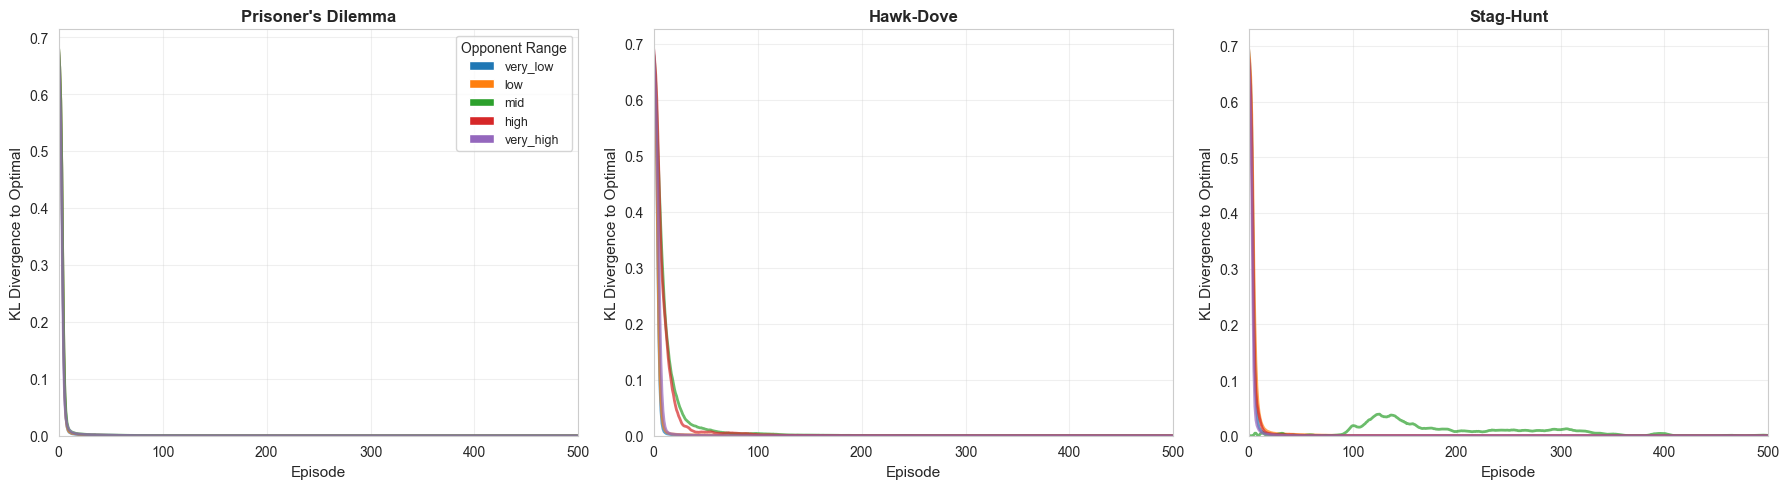

✓ KLD convergence plot saved


In [40]:
def compute_kld_binary(p_current, p_optimal, epsilon=1e-10):
    """
    Compute KL divergence between two binary policies.
    
    KLD(optimal || current) = p_opt * log(p_opt/p_curr) + (1-p_opt) * log((1-p_opt)/(1-p_curr))
    
    Args:
        p_current: Current cooperation probability
        p_optimal: Optimal cooperation probability
        epsilon: Small constant to avoid log(0)
        
    Returns:
        KL divergence value
    """
    p_curr = np.clip(p_current, epsilon, 1 - epsilon)
    p_opt = np.clip(p_optimal, epsilon, 1 - epsilon)
    
    kld = (p_opt * np.log(p_opt / p_curr) + 
           (1 - p_opt) * np.log((1 - p_opt) / (1 - p_curr)))
    
    return kld


# Define consistent colors for opponent ranges
opp_range_colors = {
    'very_low': '#1f77b4',   # Blue
    'low': '#ff7f0e',        # Orange
    'mid': '#2ca02c',        # Green
    'high': '#d62728',       # Red
    'very_high': '#9467bd'   # Purple
}

# Create 3 subplots (one per game)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for game_idx, game in enumerate(GAMES):
    ax = axes[game_idx]
    
    # Get all tasks for this game
    game_results = [r for r in convergence_results if r['game'] == game]
    
    # Plot KLD for each opponent range (no labels yet)
    for result in game_results:
        task_id = result['task_id']
        opp_range = result['opp_range']
        
        # Get cooperation series
        coop_series = result['cooperation_series']
        
        # Use final cooperation as "optimal" (equilibrium)
        optimal_coop = result['final_cooperation']
        
        # Compute KLD at each episode
        episodes = np.arange(len(coop_series))
        kld_series = compute_kld_binary(coop_series, optimal_coop)
        
        # Plot with consistent color for opponent range
        color = opp_range_colors[opp_range]
        ax.plot(episodes, kld_series, 
                color=color, 
                alpha=0.7, 
                linewidth=2)
    
    # Formatting
    ax.set_xlabel('Episode', fontsize=11)
    ax.set_ylabel('KL Divergence to Optimal', fontsize=11)
    ax.set_title(f'{GAME_FULL_NAMES[game_idx]}', fontsize=12, fontweight='bold')
    ax.set_xlim([0, 500])
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.3)

# Create custom legend with all 5 opponent ranges
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=opp_range_colors[opp], label=opp) 
                   for opp in OPPONENT_RANGES]
axes[0].legend(handles=legend_elements, title='Opponent Range', fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'kld_to_optimal_policy.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ KLD convergence plot saved")

## 9. Policy Entropy Analysis

Analyze the entropy (uncertainty) of the policy distribution over training.

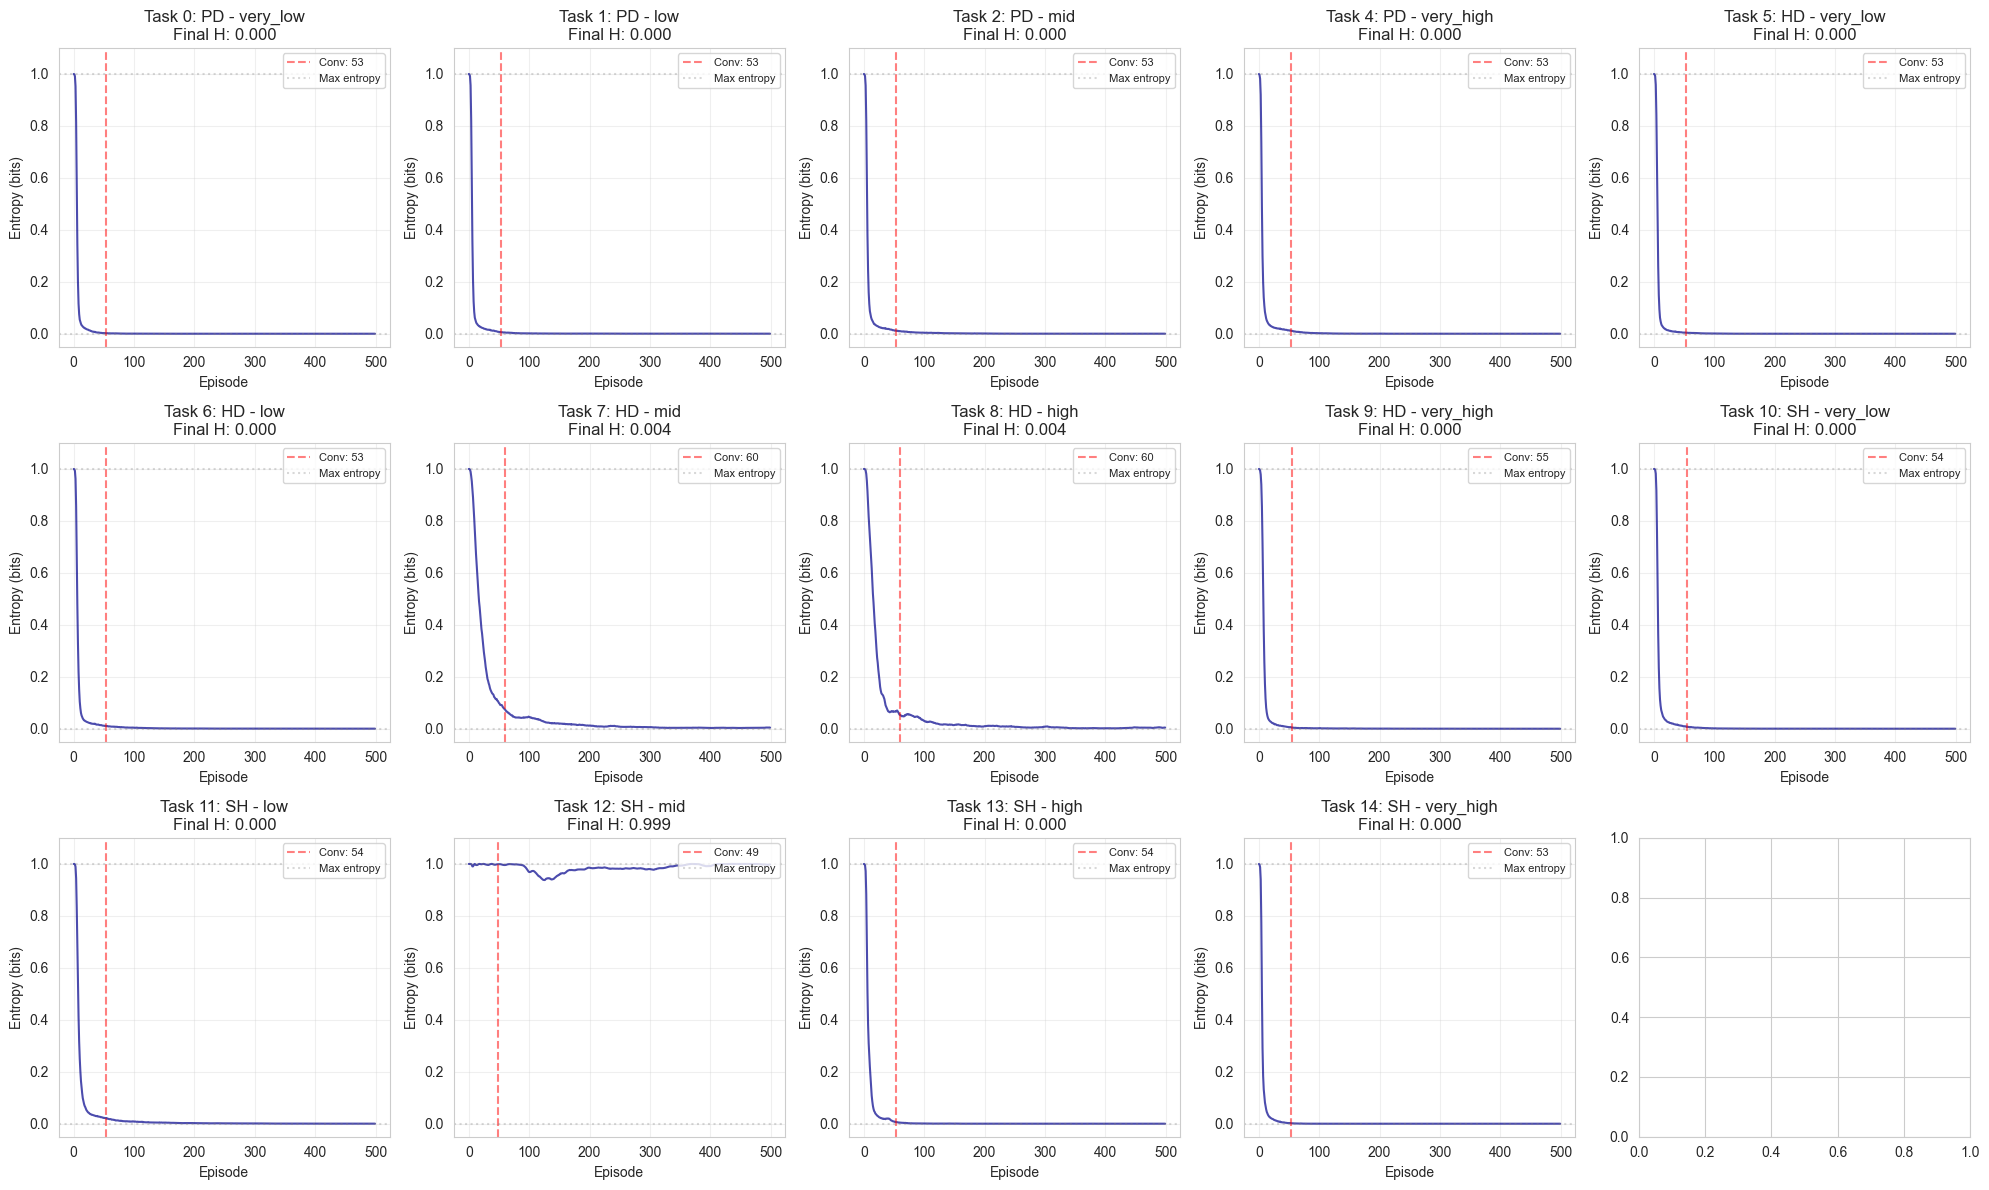

✓ Entropy trajectories plot saved

ENTROPY SUMMARY
                       mean       std       min       max
game                                                     
hawk-dove          0.001648  0.002102  0.000029  0.004293
prisoners-dilemma  0.000151  0.000092  0.000055  0.000254
stag-hunt          0.199966  0.446715  0.000097  0.999074

Interpretation:
  - High entropy (close to 0.693): Mixed/uncertain policy
  - Low entropy (close to 0.0): Deterministic policy (always cooperate or always defect)


In [41]:
# Plot entropy trajectories for all tasks
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for idx, result in enumerate(convergence_results):
    if idx >= 15:  # Only 15 tasks
        break
    
    ax = axes[idx]
    task_id = result['task_id']
    game = result['game']
    opp_range = result['opp_range']
    
    # Plot entropy over time
    episodes = np.arange(len(result['entropy_series']))
    ax.plot(episodes, result['entropy_series'], linewidth=1.5, color='darkblue', alpha=0.7)
    
    # Mark convergence point
    if result['converged']:
        ax.axvline(result['convergence_episode'], color='red', linestyle='--', 
                   alpha=0.5, label=f"Conv: {result['convergence_episode']}")
    
    # Add reference lines
    ax.axhline(np.log2(2), color='gray', linestyle=':', alpha=0.3, label='Max entropy')
    ax.axhline(0, color='gray', linestyle=':', alpha=0.3)
    
    # Labels and title
    ax.set_xlabel('Episode')
    ax.set_ylabel('Entropy (bits)')
    ax.set_title(f'Task {task_id}: {GAME_LABELS[GAMES.index(game)]} - {opp_range}\n'
                 f'Final H: {result["final_entropy"]:.3f}')
    ax.set_ylim([-0.05, 1.1])
    ax.grid(alpha=0.3)
    
    if result['converged']:
        ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'policy_entropy_trajectories.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Entropy trajectories plot saved")

# Summary statistics
print("\n" + "=" * 80)
print("ENTROPY SUMMARY")
print("=" * 80)

entropy_summary = convergence_df.groupby('game')['final_entropy'].agg(['mean', 'std', 'min', 'max'])
print(entropy_summary)

print("\nInterpretation:")
print("  - High entropy (close to 0.693): Mixed/uncertain policy")
print("  - Low entropy (close to 0.0): Deterministic policy (always cooperate or always defect)")

### 9.1 Final Cooperation Policy by Game and Opponent Type

Visualize how cooperation probability evolves over training for each task.

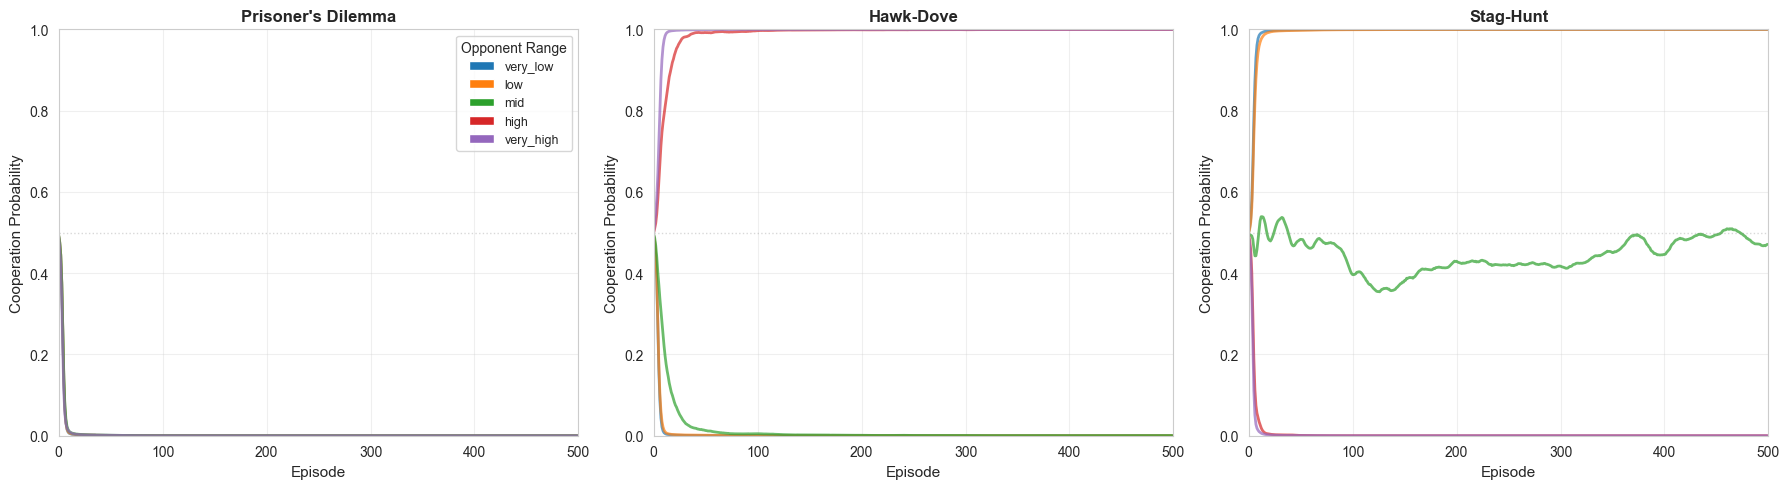

✓ Cooperation probability plot saved

FINAL COOPERATION RATES BY GAME

Prisoner's Dilemma:
  very_low: 0.000 (always_defect)
  low     : 0.000 (always_defect)
  mid     : 0.000 (always_defect)
  very_high: 0.000 (always_defect)

Hawk-Dove:
  very_low: 0.000 (always_defect)
  low     : 0.000 (always_defect)
  mid     : 0.000 (always_defect)
  high    : 1.000 (always_cooperate)
  very_high: 1.000 (always_cooperate)

Stag-Hunt:
  very_low: 1.000 (always_cooperate)
  low     : 1.000 (always_cooperate)
  mid     : 0.490 (mixed)
  high    : 0.000 (always_defect)
  very_high: 0.000 (always_defect)


In [42]:
# Create 3 subplots (one per game) showing cooperation probability over episodes
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for game_idx, game in enumerate(GAMES):
    ax = axes[game_idx]
    
    # Get all tasks for this game
    game_results = [r for r in convergence_results if r['game'] == game]
    
    # Plot cooperation probability for each task
    for result in game_results:
        task_id = result['task_id']
        opp_range = result['opp_range']
        
        # Get cooperation series
        coop_series = result['cooperation_series']
        episodes = np.arange(len(coop_series))
        
        # Plot with consistent color for opponent range
        color = opp_range_colors[opp_range]
        ax.plot(episodes, coop_series, 
                color=color, 
                alpha=0.7, 
                linewidth=2)
    
    # Formatting
    ax.set_xlabel('Episode', fontsize=11)
    ax.set_ylabel('Cooperation Probability', fontsize=11)
    ax.set_title(f'{GAME_FULL_NAMES[game_idx]}', fontsize=12, fontweight='bold')
    ax.set_xlim([0, 500])
    ax.set_ylim([0, 1])
    ax.grid(alpha=0.3)
    
    # Add reference lines for common equilibria
    ax.axhline(0.5, color='gray', linestyle=':', alpha=0.3, linewidth=1)

# Create custom legend with all 5 opponent ranges
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=opp_range_colors[opp], label=opp) 
                   for opp in OPPONENT_RANGES]
axes[0].legend(handles=legend_elements, title='Opponent Range', fontsize=9, loc='best')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cooperation_probability_by_game.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Cooperation probability plot saved")

# Print final cooperation statistics
print("\n" + "=" * 80)
print("FINAL COOPERATION RATES BY GAME")
print("=" * 80)

for game in GAMES:
    game_results = [r for r in convergence_results if r['game'] == game]
    game_label = GAME_FULL_NAMES[GAMES.index(game)]
    
    print(f"\n{game_label}:")
    for result in sorted(game_results, key=lambda x: OPPONENT_RANGES.index(x['opp_range'])):
        opp_range = result['opp_range']
        final_coop = result['final_cooperation']
        eq_type = result['equilibrium_type']
        print(f"  {opp_range:8s}: {final_coop:.3f} ({eq_type})")

## 10. Training Dynamics Summary

Summary of key findings from training analysis.

In [43]:
print("=" * 80)
print("TRAINING ANALYSIS SUMMARY")
print("=" * 80)

total_tasks = len(convergence_results)
total_converged = sum(1 for r in convergence_results if r['converged'])

print(f"\n📊 Overall Statistics:")
print(f"  - Total tasks analyzed: {total_tasks}")
print(f"  - Tasks converged: {total_converged} ({100*total_converged/total_tasks:.1f}%)")
print(f"  - Average convergence episode: {convergence_df['convergence_episode'].mean():.1f}")
print(f"  - Average final cooperation: {convergence_df['final_cooperation'].mean():.3f}")
print(f"  - Average final entropy: {convergence_df['final_entropy'].mean():.3f}")

print(f"\n🎮 By Game:")
for game in GAMES:
    game_data = convergence_df[convergence_df['game'] == game]
    game_label = GAME_FULL_NAMES[GAMES.index(game)]
    
    print(f"\n  {game_label}:")
    print(f"    - Tasks: {len(game_data)}")
    print(f"    - Converged: {game_data['convergence_episode'].notna().sum()}/{len(game_data)}")
    print(f"    - Mean convergence: {game_data['convergence_episode'].mean():.1f} episodes")
    print(f"    - Mean final cooperation: {game_data['final_cooperation'].mean():.3f}")
    print(f"    - Mean final entropy: {game_data['final_entropy'].mean():.3f}")
    print(f"    - Equilibrium distribution:")
    for eq_type, count in game_data['equilibrium_type'].value_counts().items():
        print(f"      • {eq_type}: {count}")

print("\n" + "=" * 80)
print("All plots saved to:", OUTPUT_DIR)
print("=" * 80)
print("\nGenerated files:")
print("  - kld_to_optimal_policy.png")
print("  - policy_entropy_trajectories.png")
print("  - cooperation_probability_by_game.png")

TRAINING ANALYSIS SUMMARY

📊 Overall Statistics:
  - Total tasks analyzed: 14
  - Tasks converged: 14 (100.0%)
  - Average convergence episode: 54.1
  - Average final cooperation: 0.321
  - Average final entropy: 0.072

🎮 By Game:

  Prisoner's Dilemma:
    - Tasks: 4
    - Converged: 4/4
    - Mean convergence: 53.0 episodes
    - Mean final cooperation: 0.000
    - Mean final entropy: 0.000
    - Equilibrium distribution:
      • always_defect: 4

  Hawk-Dove:
    - Tasks: 5
    - Converged: 5/5
    - Mean convergence: 56.2 episodes
    - Mean final cooperation: 0.400
    - Mean final entropy: 0.002
    - Equilibrium distribution:
      • always_defect: 3
      • always_cooperate: 2

  Stag-Hunt:
    - Tasks: 5
    - Converged: 5/5
    - Mean convergence: 52.8 episodes
    - Mean final cooperation: 0.498
    - Mean final entropy: 0.200
    - Equilibrium distribution:
      • always_cooperate: 2
      • always_defect: 2
      • mixed: 1

All plots saved to: c:\Users\User\OneDrive - hu

---
## 11. Test Phase Analysis - Generalization Performance

Analyze how trained agents generalize to new games and opponent types.

### Test Conditions Structure
For each training task (15 total), we test on 9 conditions:
- **1 Baseline**: Same game + same opponent range 
- **4 Same Game**: Same game + 4 other opponent ranges
- **4 New Games**: 2 other games × 2 opponent ranges each

### Opponent Range Labels
The experiment uses: **very_low, low, mid, high, very_high**

### Visualization Goal
Create normalized heatmaps showing:
- **Training conditions** (rows): 15 tasks = 3 games × 5 opponent ranges
- **Test conditions** (columns): 9 test conditions per task
- **Color**: Normalized reward (0-1 scale, normalized per game's payoff range)

## 12. Helper Functions - Test Data Extraction

In [44]:
def extract_test_matrix_data():
    """
    Extract test performance into matrix format for heatmap visualization.
    
    Returns:
        dict: Contains reward_matrix, cooperation_matrix, condition_labels
    """
    # Initialize storage
    test_data_records = []
    
    print("Extracting test data from all tasks...")
    print("=" * 80)
    
    for task_id in range(num_tasks):
        train_game, train_opp_range, _ = TRAINING_CONDITIONS[task_id]
        
        # Get test results for this task
        task_test = aggregated_data.get(task_id, {}).get('test_agg')
        
        if task_test is None or 'evaluation_summaries' not in task_test:
            print(f"Task {task_id:2d}: No test data found")
            continue
        
        eval_summaries = task_test['evaluation_summaries']
        
        # Extract each test condition
        for condition_key, summary in eval_summaries.items():
            # Parse condition
            if condition_key == 'baseline':
                test_game = train_game
                test_opp_range = train_opp_range
                condition_type = 'baseline'
            elif condition_key.startswith('same_game_'):
                test_game = train_game
                test_opp_range = condition_key.replace('same_game_', '')
                condition_type = 'same_game'
            elif '_same_opponents' in condition_key:
                test_game = condition_key.replace('_same_opponents', '')
                test_opp_range = train_opp_range
                condition_type = 'new_game'
            else:
                # Format: <game>_<opponent_range>
                parts = condition_key.rsplit('_', 1)
                if len(parts) == 2:
                    test_game = parts[0]
                    test_opp_range = parts[1]
                    condition_type = 'new_game_new_opp'
                else:
                    continue
            
            # Extract metrics
            mean_reward = summary.get('mean_reward', 0.0)
            mean_coop = summary.get('mean_cooperation_rate', 0.0)
            
            # Normalize reward by game's payoff range
            min_r, max_r = GAME_PAYOFF_RANGES.get(test_game, (0, 1))
            if max_r != min_r:
                normalized_reward = (mean_reward - min_r) / (max_r - min_r)
            else:
                normalized_reward = 0.5
            normalized_reward = np.clip(normalized_reward, 0, 1)
            
            test_data_records.append({
                'task_id': task_id,
                'train_game': train_game,
                'train_opp_range': train_opp_range,
                'test_game': test_game,
                'test_opp_range': test_opp_range,
                'condition_key': condition_key,
                'condition_type': condition_type,
                'mean_reward': mean_reward,
                'normalized_reward': normalized_reward,
                'mean_cooperation': mean_coop
            })
        
        print(f"Task {task_id:2d} ({train_game:20s} - {train_opp_range:7s}): "
              f"{len(eval_summaries)} test conditions extracted")
    
    # Convert to DataFrame
    test_df = pd.DataFrame(test_data_records)
    
    print("\n" + "=" * 80)
    print(f"Total test records extracted: {len(test_df)}")
    print(f"Expected: {num_tasks * 9} = {num_tasks} tasks × 9 conditions")
    print("=" * 80)
    
    return test_df


print("✓ Test data extraction helper function defined")

✓ Test data extraction helper function defined


### 12.1 Configuration Verification

Verify that the notebook configuration matches the actual experiment labels.

In [45]:
# Verify notebook configuration matches experiment
print("=" * 80)
print("CONFIGURATION VERIFICATION")
print("=" * 80)

all_condition_keys = set()
for task_id in range(num_tasks):
    task_test = aggregated_data.get(task_id, {}).get('test_agg')
    if task_test and 'evaluation_summaries' in task_test:
        eval_summaries = task_test['evaluation_summaries']
        all_condition_keys.update(eval_summaries.keys())

# Extract opponent range labels from condition keys
opponent_ranges_in_test = set()
for key in all_condition_keys:
    if key == 'baseline':
        continue
    elif key.startswith('same_game_'):
        opp_range = key.replace('same_game_', '')
        opponent_ranges_in_test.add(opp_range)
    elif '_same_opponents' in key:
        continue
    else:
        # Format: <game>_<opponent_range>
        parts = key.rsplit('_', 1)
        if len(parts) == 2 and parts[0] in GAMES:
            opponent_ranges_in_test.add(parts[1])

print(f"\nNotebook configuration:  {OPPONENT_RANGES}")
print(f"Experiment test data:    {sorted(opponent_ranges_in_test)}")

if opponent_ranges_in_test == set(OPPONENT_RANGES):
    print(f"\n✓ Configuration matches experiment data")
else:
    print(f"\n✗ MISMATCH DETECTED!")
    print(f"  Extra in test:     {sorted(opponent_ranges_in_test - set(OPPONENT_RANGES))}")
    print(f"  Missing from test: {sorted(set(OPPONENT_RANGES) - opponent_ranges_in_test)}")

print(f"\nTotal unique condition keys: {len(all_condition_keys)}")
print("All condition keys found:")
for key in sorted(all_condition_keys):
    print(f"  - {key}")


CONFIGURATION VERIFICATION

Notebook configuration:  ['very_low', 'low', 'mid', 'high', 'very_high']
Experiment test data:    ['high', 'low', 'mid', 'very_high', 'very_low']

✓ Configuration matches experiment data

Total unique condition keys: 15
All condition keys found:
  - baseline
  - hawk-dove_high
  - hawk-dove_low
  - hawk-dove_same_opponents
  - prisoners-dilemma_high
  - prisoners-dilemma_low
  - prisoners-dilemma_same_opponents
  - same_game_high
  - same_game_low
  - same_game_mid
  - same_game_very_high
  - same_game_very_low
  - stag-hunt_high
  - stag-hunt_low
  - stag-hunt_same_opponents


## 13. Extract Test Data

In [46]:
# Extract all test data
test_matrix_df = extract_test_matrix_data()

# Display summary
print("\nTest data summary:")
print(test_matrix_df.groupby('condition_type').size())

print("\nSample test records:")
print(test_matrix_df.head(10).to_string(index=False))

# Check for missing data
print("\n" + "=" * 80)
print("MISSING DATA CHECK")
print("=" * 80)
missing_by_task = test_matrix_df.groupby('task_id').size()
print(f"\nTest conditions per task:")
print(missing_by_task.to_string())

incomplete_tasks = missing_by_task[missing_by_task < 9]
if len(incomplete_tasks) > 0:
    print(f"\n⚠ Tasks with incomplete test data ({len(incomplete_tasks)}):")
    print(incomplete_tasks.to_string())
else:
    print("\n✓ All tasks have complete test data (9 conditions each)")

Extracting test data from all tasks...
Task  0 (prisoners-dilemma    - very_low): 9 test conditions extracted
Task  1 (prisoners-dilemma    - low    ): 9 test conditions extracted
Task  2 (prisoners-dilemma    - mid    ): 9 test conditions extracted
Task  3 (prisoners-dilemma    - high   ): 9 test conditions extracted
Task  4 (prisoners-dilemma    - very_high): 9 test conditions extracted
Task  5 (hawk-dove            - very_low): 9 test conditions extracted
Task  6 (hawk-dove            - low    ): 9 test conditions extracted
Task  7 (hawk-dove            - mid    ): 9 test conditions extracted
Task  8 (hawk-dove            - high   ): 9 test conditions extracted
Task  9 (hawk-dove            - very_high): 9 test conditions extracted
Task 10 (stag-hunt            - very_low): 9 test conditions extracted
Task 11 (stag-hunt            - low    ): 9 test conditions extracted
Task 12 (stag-hunt            - mid    ): 9 test conditions extracted
Task 13 (stag-hunt            - high   ): 9 

### 13.1 Test Coverage Analysis

Understand which test conditions were actually run (and why there are missing cells).

In [ ]:
# Analyze test coverage pattern
print("=" * 80)
print("TEST COVERAGE ANALYSIS")
print("=" * 80)

# Analyze Task 0 as example
task_0_data = test_matrix_df[test_matrix_df['task_id'] == 0]
train_game_0 = task_0_data['train_game'].iloc[0]
train_opp_0 = task_0_data['train_opp_range'].iloc[0]

print(f"\nEXAMPLE: Task 0 (trained on {train_game_0} + {train_opp_0})")
print(f"Total test conditions: {len(task_0_data)}")
print(f"\nTest breakdown by game:")
for game in GAMES:
    game_tests = task_0_data[task_0_data['test_game'] == game]
    opp_ranges = sorted(game_tests['test_opp_range'].unique())
    print(f"  {game:20s}: {len(game_tests)} conditions → opponent ranges: {opp_ranges}")

print(f"\n" + "=" * 80)
print("EXPERIMENTAL DESIGN PATTERN")
print("=" * 80)
print("For each training task, 9 test conditions are run:")
print("  1. BASELINE: Same game + same opponent range (1 condition)")
print("  2. SAME GAME: Same game + 4 other opponent ranges (4 conditions)")
print("  3. CROSS-GAME: 2 other games × 2-3 opponent ranges each (4 conditions)")
print()
print("Total possible combinations: 3 games × 5 opponents = 15")
print("Actually tested per task: 9 conditions")
print("Missing (not tested): 6 conditions per task")
print()
print("This explains the NaN values (empty cells) in the heatmaps!")

# Count overall coverage
total_possible = num_tasks * 3 * 5  # 15 tasks × 3 games × 5 opponents
total_tested = len(test_matrix_df)
print(f"\n" + "=" * 80)
print("OVERALL TEST COVERAGE")
print("=" * 80)
print(f"Total possible test combinations: {total_possible}")
print(f"Total actually tested: {total_tested}")
print(f"Coverage: {100 * total_tested / total_possible:.1f}%")
print(f"Missing: {total_possible - total_tested} test conditions")

### 13.2 Heatmap Structure Verification

In [ ]:
# Verify pivot table structure for all tasks
print("=" * 80)
print("HEATMAP DIMENSIONS FOR ALL TASKS")
print("=" * 80)
print("(Note: Each heatmap is 3×5 grid, but not all cells have data)")
print()

for task_id in range(num_tasks):
    task_data = test_matrix_df[test_matrix_df['task_id'] == task_id]
    if len(task_data) > 0:
        pivot = task_data.pivot_table(
            index='test_game',
            columns='test_opp_range',
            values='normalized_reward',
            aggfunc='mean'
        )
        train_game, train_opp_range, _ = TRAINING_CONDITIONS[task_id]
        filled_cells = pivot.notna().sum().sum()
        total_cells = pivot.shape[0] * pivot.shape[1]
        print(f"Task {task_id:2d} ({train_game:20s} - {train_opp_range:8s}): "
              f"{filled_cells:2d}/{total_cells} cells filled")

print(f"\n✓ All tasks have 3×5 grids with ~9 filled cells each")
print(f"✓ Missing cells = test conditions that were not run (by design)")

TEST DATA STRUCTURE FOR HEATMAP

Unique test games: ['hawk-dove', 'prisoners-dilemma', 'stag-hunt']
Count: 3

Unique test opponent ranges: ['high', 'low', 'mid', 'very_high', 'very_low']
Count: 5

SAMPLE: Task 0 data structure

Total test conditions for task 0: 9

Pivot table shape for task 0: (3, 5)
Rows (test games): ['hawk-dove', 'prisoners-dilemma', 'stag-hunt']
Columns (test opponent ranges): ['high', 'low', 'mid', 'very_high', 'very_low']

Pivot table:
test_opp_range     high     low  mid  very_high  very_low
test_game                                                
hawk-dove           NaN  0.6778  NaN        NaN     0.762
prisoners-dilemma   1.0  1.0000  1.0        1.0     1.000
stag-hunt           NaN  0.4000  NaN        NaN     0.400

HEATMAP DIMENSIONS FOR ALL TASKS
Task 0 (prisoners-dilemma    - very_low): Heatmap shape = 3 rows × 5 cols
Task 1 (prisoners-dilemma    - low    ): Heatmap shape = 3 rows × 5 cols
Task 2 (prisoners-dilemma    - mid    ): Heatmap shape = 3 rows × 

## 14. Create Generalization Heatmaps

Visualize generalization performance as 15 separate heatmaps (one per training task):
- **Subplot layout**: 3 rows (games) × 5 columns (opponent ranges) = 15 subplots
- **Y-axis per subplot**: Test games (alphabetical order)
- **X-axis per subplot**: Test opponent ranges (very_low, low, mid, high, very_high)
- **Color**: Normalized reward (0 = worst, 1 = best for that game)

**Note about missing cells (white/empty):** The experiment does NOT test all 15 possible combinations (3 games × 5 opponents) for each training task. Instead, it tests 9 specific conditions per task:
- Same game: all 5 opponent ranges
- Other games: only 2 opponent ranges each (typically `low` and training range)

Empty cells represent test combinations that were **not run** as part of the experimental design.

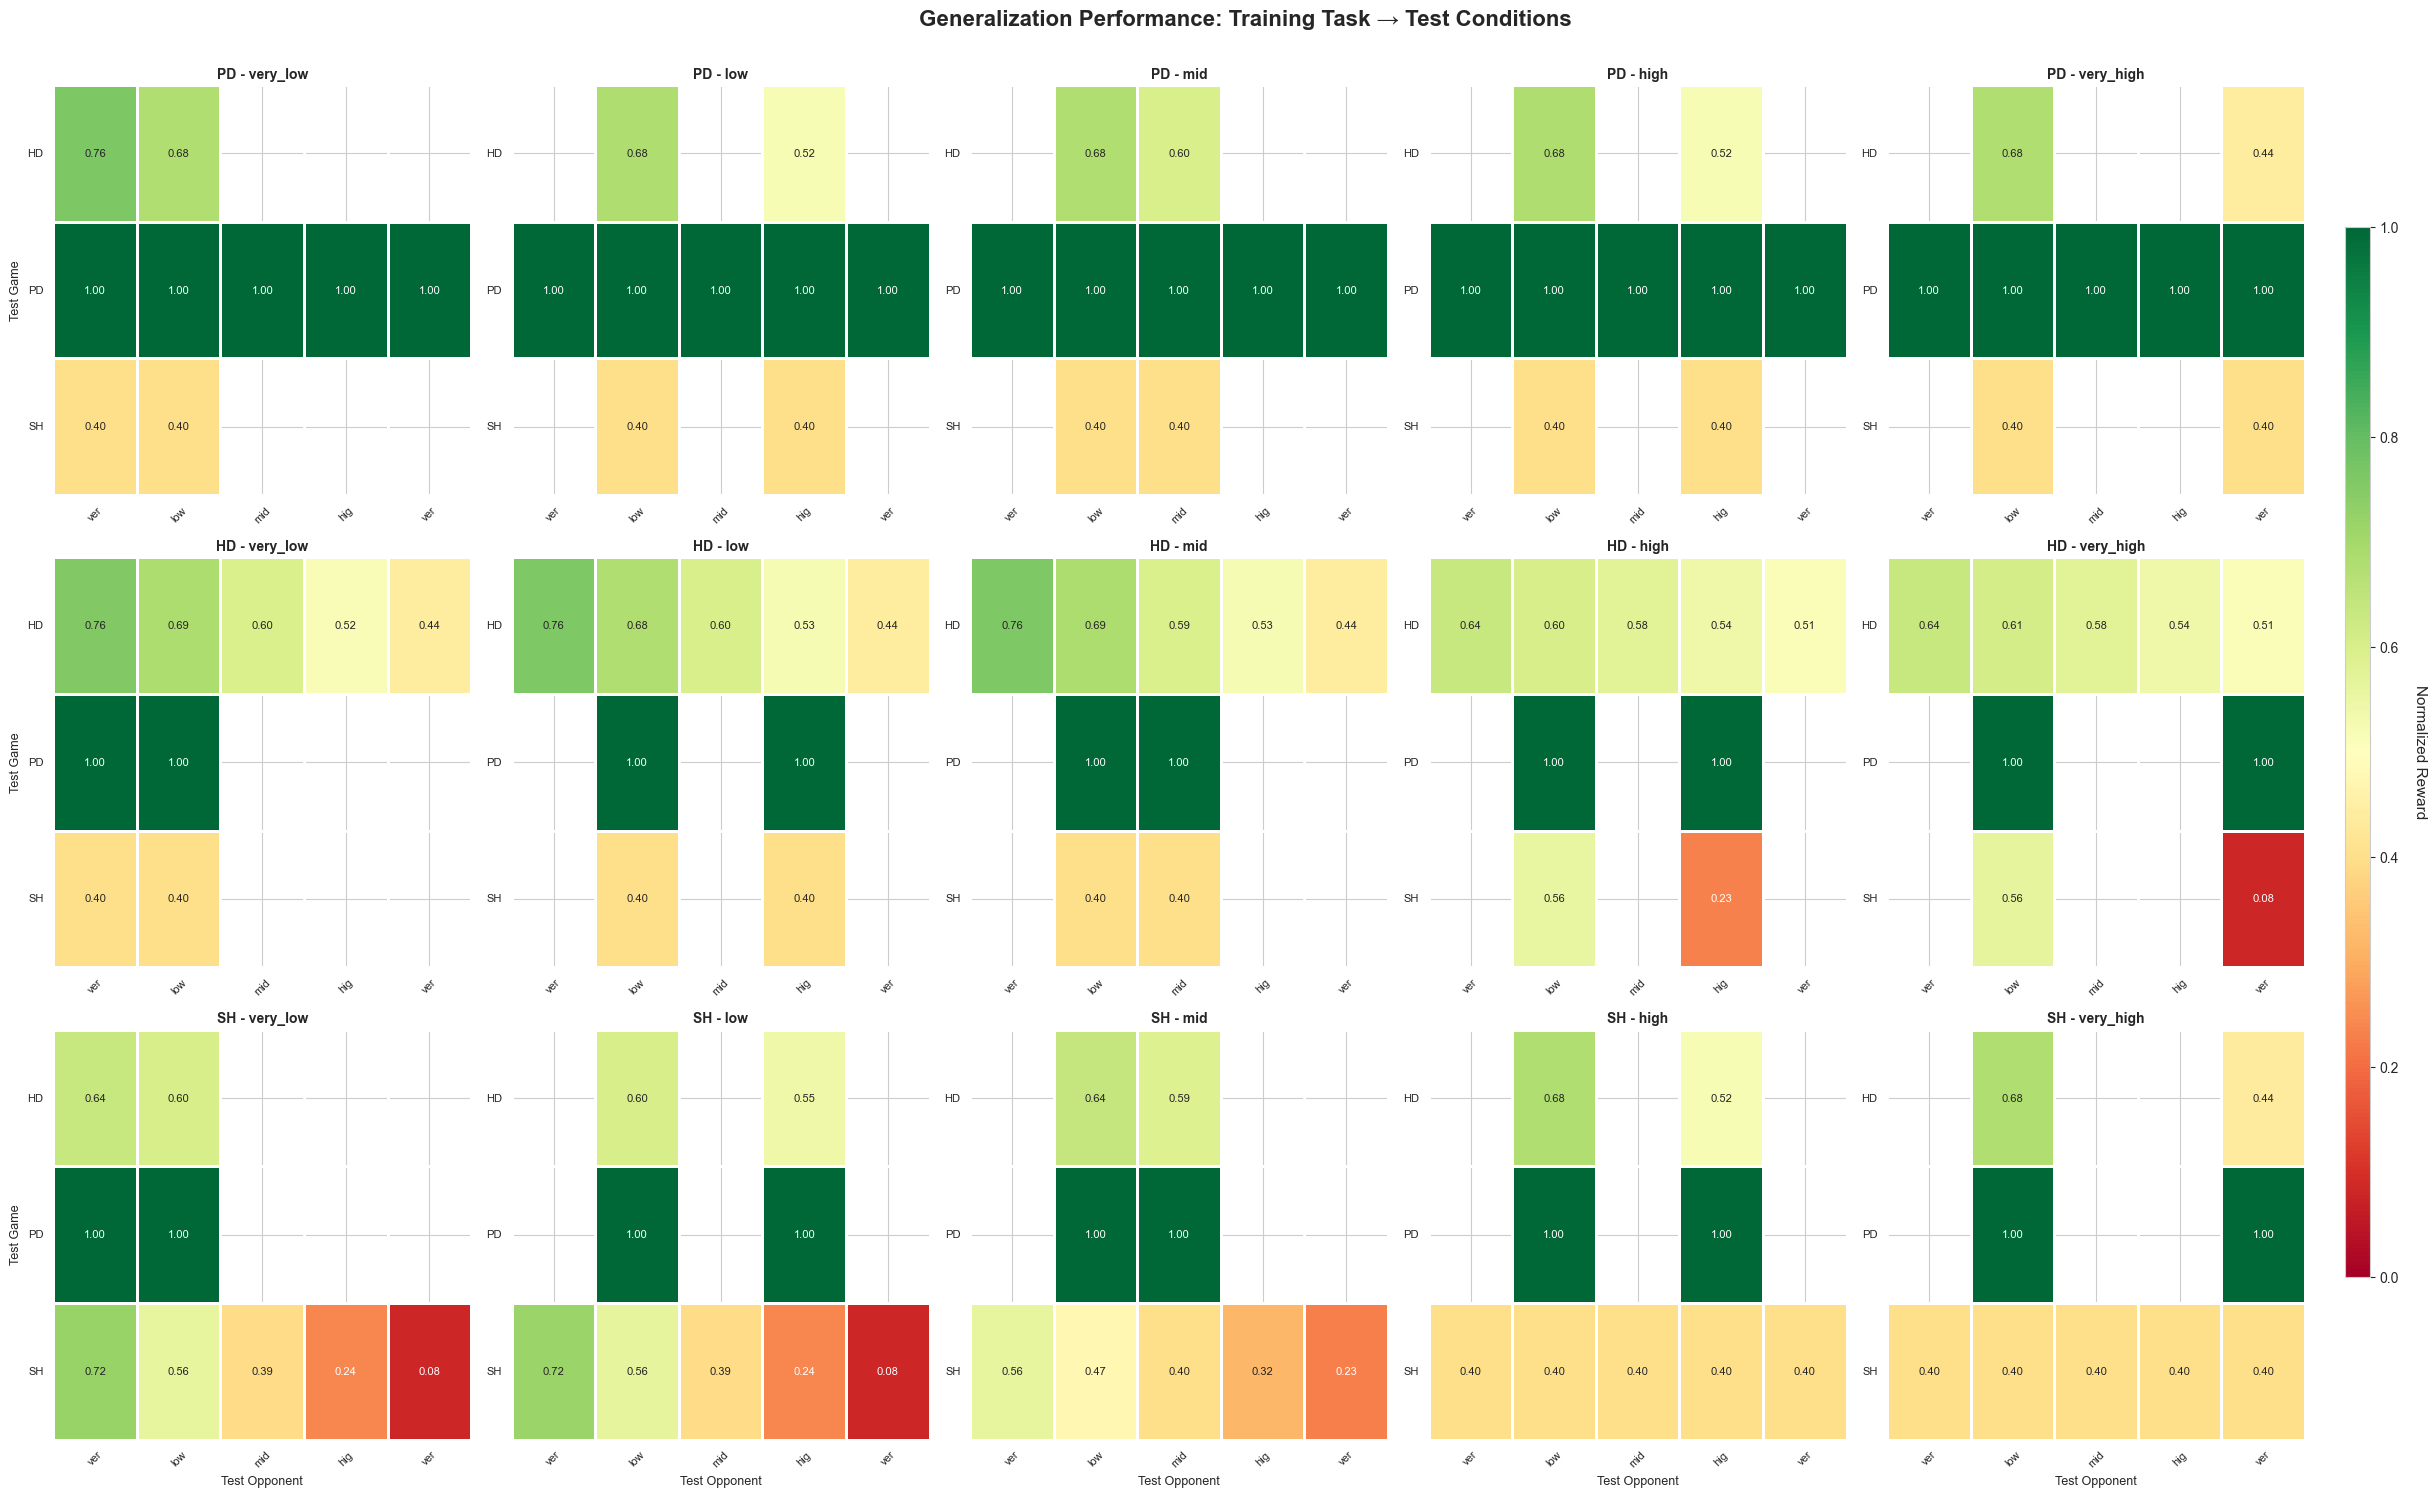

✓ Per-task generalization heatmaps saved


In [ ]:
# Create 15-subplot heatmap: one subplot per training task
def create_per_task_heatmaps(test_df, metric='normalized_reward'):
    """
    Create grid of heatmaps, one per training task.
    Each heatmap shows: Y-axis = test games, X-axis = test opponent ranges.
    
    Args:
        test_df: DataFrame with test results
        metric: 'normalized_reward' or 'mean_cooperation'
    """
    # Create figure with 3 rows (games) × 5 columns (opponent ranges)
    fig, axes = plt.subplots(3, 5, figsize=(25, 15))
    
    # Sort games alphabetically for y-axis
    test_games_sorted = sorted(GAMES)
    
    # Iterate through all 15 training tasks
    for task_id in range(num_tasks):
        train_game, train_opp_range, _ = TRAINING_CONDITIONS[task_id]
        
        # Determine subplot position
        game_idx = GAMES.index(train_game)  # Row
        opp_idx = OPPONENT_RANGES.index(train_opp_range)  # Column
        
        ax = axes[game_idx, opp_idx]
        
        # Filter data for this training task
        task_data = test_df[test_df['task_id'] == task_id].copy()
        
        if len(task_data) == 0:
            ax.text(0.5, 0.5, 'No Data', ha='center', va='center', fontsize=10)
            ax.set_title(f'{GAME_LABELS[game_idx]}\n{train_opp_range}', 
                        fontsize=10, fontweight='bold')
            ax.set_xticks([])
            ax.set_yticks([])
            continue
        
        # Create pivot table: rows = test games, columns = test opponent ranges
        pivot = task_data.pivot_table(
            index='test_game',
            columns='test_opp_range',
            values=metric,
            aggfunc='mean'
        )
        
        # Reorder rows (games) alphabetically
        pivot = pivot.reindex(test_games_sorted)
        
        # Reorder columns (opponent ranges) by order
        available_opp_ranges = [opp for opp in OPPONENT_RANGES if opp in pivot.columns]
        if available_opp_ranges:
            pivot = pivot[available_opp_ranges]
        
        # Create row labels (game abbreviations)
        row_labels = [GAME_LABELS[GAMES.index(game)] if game in GAMES else game[:2].upper() 
                      for game in pivot.index]
        
        # Create column labels (opponent range abbreviations)
        col_labels = [opp[:3] for opp in pivot.columns]
        
        # Plot heatmap
        sns.heatmap(pivot.values, 
                    ax=ax,
                    cmap='RdYlGn',
                    vmin=0, vmax=1,
                    cbar=False,  # No individual colorbars
                    xticklabels=col_labels,
                    yticklabels=row_labels,
                    linewidths=1,
                    linecolor='gray',
                    annot=True,  # Show values
                    fmt='.2f',
                    annot_kws={'fontsize': 8},
                    cbar_kws={'label': 'Normalized Reward'},
                    mask=pivot.isna())  # Mask missing values (will show as white)
        
        # Manually mark missing cells with light gray background
        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                if pd.isna(pivot.values[i, j]):
                    ax.add_patch(plt.Rectangle((j, i), 1, 1, 
                                              fill=True, facecolor='lightgray', 
                                              edgecolor='gray', linewidth=1, alpha=0.3))
        
        # Title: Training game + opponent range
        ax.set_title(f'{GAME_LABELS[game_idx]} - {train_opp_range}', 
                    fontsize=10, fontweight='bold', pad=5)
        
        # Labels
        if opp_idx == 0:  # Leftmost column
            ax.set_ylabel('Test Game', fontsize=9)
        else:
            ax.set_ylabel('')
            
        if game_idx == 2:  # Bottom row
            ax.set_xlabel('Test Opponent', fontsize=9)
        else:
            ax.set_xlabel('')
        
        ax.tick_params(axis='both', labelsize=8)
        ax.tick_params(axis='x', rotation=45)
        ax.tick_params(axis='y', rotation=0)
    
    # Add single colorbar for entire figure
    fig.subplots_adjust(right=0.92)
    cbar_ax = fig.add_axes([0.94, 0.15, 0.01, 0.7])  # [left, bottom, width, height]
    sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label('Normalized Reward', fontsize=11, rotation=270, labelpad=20)
    
    # Add overall title
    fig.suptitle('Generalization Performance: Training Task → Test Conditions\n' +
                 '(Gray cells = test conditions not run)', 
                 fontsize=16, fontweight='bold', y=0.998)
    
    plt.tight_layout(rect=[0, 0, 0.93, 0.99])
    plt.savefig(OUTPUT_DIR / 'generalization_heatmaps_per_task.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Per-task generalization heatmaps saved")
    print("  Note: Gray cells indicate test conditions that were not run")
    print(f"  Each task tests ~9 out of 15 possible conditions")


# Create the heatmaps
create_per_task_heatmaps(test_matrix_df, metric='normalized_reward')

## 15. Summary Statistics by Training Task

Compute summary statistics for each training task's generalization performance.

In [49]:
# Compute generalization statistics for each training task
print("=" * 80)
print("GENERALIZATION STATISTICS BY TRAINING TASK")
print("=" * 80)

for task_id in range(num_tasks):
    train_game, train_opp_range, _ = TRAINING_CONDITIONS[task_id]
    task_data = test_matrix_df[test_matrix_df['task_id'] == task_id]
    
    if len(task_data) == 0:
        continue
    
    # Get baseline performance
    baseline = task_data[task_data['condition_type'] == 'baseline']
    baseline_reward = baseline['normalized_reward'].mean() if len(baseline) > 0 else np.nan
    
    # Performance by condition type
    same_game = task_data[task_data['condition_type'] == 'same_game']
    new_game = task_data[task_data['condition_type'] == 'new_game']
    cross_gen = task_data[task_data['condition_type'] == 'new_game_new_opp']
    
    print(f"\n[Task {task_id}] {train_game.upper()} trained on {train_opp_range} opponents")
    print(f"  Baseline (same game/opp):     {baseline_reward:.3f}")
    print(f"  Same game, diff opp:          {same_game['normalized_reward'].mean():.3f} (n={len(same_game)})")
    print(f"  New game, same opp:           {new_game['normalized_reward'].mean():.3f} (n={len(new_game)})")
    print(f"  New game, new opp:            {cross_gen['normalized_reward'].mean():.3f} (n={len(cross_gen)})")
    
    # Generalization gaps
    if not np.isnan(baseline_reward):
        print(f"  Generalization gaps from baseline:")
        print(f"    → Same game:  {baseline_reward - same_game['normalized_reward'].mean():+.3f}")
        print(f"    → New game:   {baseline_reward - new_game['normalized_reward'].mean():+.3f}")
        print(f"    → Cross-gen:  {baseline_reward - cross_gen['normalized_reward'].mean():+.3f}")

GENERALIZATION STATISTICS BY TRAINING TASK

[Task 0] PRISONERS-DILEMMA trained on very_low opponents
  Baseline (same game/opp):     1.000
  Same game, diff opp:          1.000 (n=4)
  New game, same opp:           0.581 (n=2)
  New game, new opp:            0.539 (n=2)
  Generalization gaps from baseline:
    → Same game:  +0.000
    → New game:   +0.419
    → Cross-gen:  +0.461

[Task 1] PRISONERS-DILEMMA trained on low opponents
  Baseline (same game/opp):     1.000
  Same game, diff opp:          1.000 (n=4)
  New game, same opp:           0.540 (n=2)
  New game, new opp:            0.461 (n=2)
  Generalization gaps from baseline:
    → Same game:  +0.000
    → New game:   +0.460
    → Cross-gen:  +0.538

[Task 2] PRISONERS-DILEMMA trained on mid opponents
  Baseline (same game/opp):     1.000
  Same game, diff opp:          1.000 (n=4)
  New game, same opp:           0.500 (n=2)
  New game, new opp:            0.540 (n=2)
  Generalization gaps from baseline:
    → Same game:  +0.0

## 16. Generalization Analysis Summary

In [50]:
print("=" * 80)
print("TEST PHASE GENERALIZATION ANALYSIS")
print("=" * 80)

# Overall statistics
print(f"\n📊 Overall Test Statistics:")
print(f"  - Tasks tested: {test_matrix_df['task_id'].nunique()}")
print(f"  - Total test evaluations: {len(test_matrix_df)}")
print(f"  - Mean normalized reward: {test_matrix_df['normalized_reward'].mean():.3f}")
print(f"  - Mean cooperation rate: {test_matrix_df['mean_cooperation'].mean():.3f}")

# By condition type
print(f"\n📈 Performance by Condition Type:")
condition_stats = test_matrix_df.groupby('condition_type').agg({
    'normalized_reward': ['mean', 'std', 'count'],
    'mean_cooperation': ['mean', 'std']
}).round(3)
print(condition_stats.to_string())

# By training game
print(f"\n🎮 Performance by Training Game:")
game_stats = test_matrix_df.groupby('train_game').agg({
    'normalized_reward': ['mean', 'std'],
    'mean_cooperation': ['mean', 'std']
}).round(3)
print(game_stats.to_string())

# Compute generalization gaps
print(f"\n📉 Generalization Gaps (Baseline vs Other Conditions):")
baseline_perf = test_matrix_df[test_matrix_df['condition_type'] == 'baseline'].groupby('train_game')['normalized_reward'].mean()

for cond_type in ['same_game', 'new_game', 'new_game_new_opp']:
    cond_perf = test_matrix_df[test_matrix_df['condition_type'] == cond_type].groupby('train_game')['normalized_reward'].mean()
    
    print(f"\n  {cond_type.replace('_', ' ').title()}:")
    for game in GAMES:
        if game in baseline_perf.index and game in cond_perf.index:
            gap = baseline_perf[game] - cond_perf[game]
            print(f"    {game:20s}: Δ = {gap:+.3f}")

print("\n" + "=" * 80)
print("All test phase plots saved to:", OUTPUT_DIR)
print("=" * 80)
print("\nAdditional generated files:")
print("  - generalization_heatmaps_per_task.png (15 subplots, one per training task)")

TEST PHASE GENERALIZATION ANALYSIS

📊 Overall Test Statistics:
  - Tasks tested: 15
  - Total test evaluations: 135
  - Mean normalized reward: 0.665
  - Mean cooperation rate: 0.302

📈 Performance by Condition Type:
                 normalized_reward              mean_cooperation       
                              mean    std count             mean    std
condition_type                                                         
baseline                     0.705  0.241    15            0.302  0.456
new_game                     0.643  0.286    30            0.302  0.448
new_game_new_opp             0.690  0.244    30            0.302  0.448
same_game                    0.653  0.281    60            0.302  0.444

🎮 Performance by Training Game:
                  normalized_reward        mean_cooperation       
                               mean    std             mean    std
train_game                                                        
hawk-dove                     0.635  0.234   